# Pick-time calibration

Tune the pick-time regression by **physical anchors (seconds)**, not raw coefficients.
The live curves use the *real* `Pick._pick_time`, so what you tune equals what the sim charges.

Formula: `pick_time = pick_intercept + qty*(pick_weight_coef*ln(w) + pick_volume_coef*ln(v)) + cart_swap_coef*swapped`  
Travel: `|dx|*x_speed + |dy|*y_speed`.

Drag the sliders until a typical pick is ~10x a single travel step and the per-quantity shape looks right; the derived coefficients print at the bottom, ready to paste into `REGRESSION_CONFIGS` / `PickConfig`.

In [1]:
import os, sys, math, pathlib
import numpy as np
import matplotlib.pyplot as plt

# find repo root (dir containing Warehouse/) walking up from cwd
p = pathlib.Path.cwd()
while p != p.parent and not (p / 'Warehouse').exists():
    p = p.parent
ROOT = str(p)
for sub in ('Warehouse', 'Optimization'):
    d = os.path.join(ROOT, sub)
    if d not in sys.path:
        sys.path.insert(0, d)

from Pick import PickConfig, _pick_time   # the REAL sim formula
try:
    import ipywidgets as W
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False
print('repo root:', ROOT, '| widgets:', _HAVE_WIDGETS)

repo root: c:\Users\myfir\Code and Repos\Inventory_Location_Optimizer | widgets: True


In [2]:
# Reference archetypes (weight, volume) spanning the carton distribution, and a
# representative aisle task, used only to DISPLAY shapes/ratios (not the sim).
ITEMS = {
    'light':   (3,    27),
    'typical': (20,   27_000),
    'heavy':   (55,   110_000),
    'bulky':   (15,   110_000),
}
W0, V0 = ITEMS['typical']        # anchor item for the per-unit handling anchor
COL_STEP = 48                    # pallet column physical step (Aisle_Dimensions)
LVL_STEP = 48                    # extra_large level step
REF_TASK_COLUMNS = 8             # distinct columns the picker sweeps
REF_TASK_LEVELS  = 4             # vertical movement (levels)
REF_TASK_PICKS   = 8             # pick stops in the task
REF_TASK_QTY     = 2             # units per pick

In [3]:
def derive_coeffs(setup_sec, handle_sec_per_unit, weight_share,
                  walk_sec_per_column, walk_sec_per_level, cart_swap_sec):
    """Map physical anchors (seconds) -> raw PickConfig coefficients."""
    lnW, lnV = math.log(max(W0, 1)), math.log(max(V0, 1))
    pw = weight_share * handle_sec_per_unit / lnW if lnW else 0.0
    pv = (1 - weight_share) * handle_sec_per_unit / lnV if lnV else 0.0
    return dict(
        pick_intercept=setup_sec,
        pick_weight_coef=pw,
        pick_volume_coef=pv,
        x_speed=walk_sec_per_column / COL_STEP,
        y_speed=walk_sec_per_level / LVL_STEP,
        cart_swap_coef=cart_swap_sec,
    )

In [4]:
def render(setup_sec=3.0, handle_sec_per_unit=5.0, weight_share=0.7,
           walk_sec_per_column=0.4, walk_sec_per_level=0.25, cart_swap_sec=30.0,
           config_name='calibrated',
           pick_intercept=None, pick_weight_coef=None, pick_volume_coef=None,
           x_speed=None, y_speed=None, cart_swap_coef=None):
    c = derive_coeffs(setup_sec, handle_sec_per_unit, weight_share,
                      walk_sec_per_column, walk_sec_per_level, cart_swap_sec)
    overrides = dict(pick_intercept=pick_intercept, pick_weight_coef=pick_weight_coef,
                     pick_volume_coef=pick_volume_coef, x_speed=x_speed,
                     y_speed=y_speed, cart_swap_coef=cart_swap_coef)
    for k, v in overrides.items():
        if v is not None:
            c[k] = v
    cfg = PickConfig(**c)

    qs = np.arange(1, 21)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    ax = axes[0]
    for name, (w, v) in ITEMS.items():
        ax.plot(qs, [_pick_time(cfg, w, v, int(q), False) for q in qs], marker='o', ms=3, label=name)
    ax.set_xlabel('quantity'); ax.set_ylabel('pick time (s)')
    ax.set_title('Pick time vs quantity (real _pick_time)'); ax.legend(); ax.grid(alpha=.3)

    ax = axes[1]
    ws = np.linspace(1, 60, 80)
    ax.plot(ws, [c['pick_weight_coef'] * math.log(max(w, 1)) for w in ws], label='weight term / unit')
    vs = np.linspace(27, 110_000, 80)
    ax.plot(ws, [c['pick_volume_coef'] * math.log(max(v, 1)) for v in vs], label='volume term / unit (vol swept)')
    ax.set_xlabel('weight (volume co-swept)'); ax.set_ylabel('s / unit')
    ax.set_title('Per-unit handling components'); ax.legend(fontsize=8); ax.grid(alpha=.3)

    ax = axes[2]
    w, v = ITEMS['typical']
    handling = REF_TASK_PICKS * _pick_time(cfg, w, v, REF_TASK_QTY, False)
    travel = REF_TASK_COLUMNS * COL_STEP * cfg.x_speed + REF_TASK_LEVELS * LVL_STEP * cfg.y_speed
    ax.bar(['travel', 'handling'], [travel, handling], color=['#4c72b0', '#dd8452'])
    ax.set_ylabel('time (s)'); ax.set_title('Reference task (~8 picks)'); ax.grid(axis='y', alpha=.3)
    plt.tight_layout(); plt.show()

    one_pick = _pick_time(cfg, w, v, REF_TASK_QTY, False)
    one_step = COL_STEP * cfg.x_speed
    tot = travel + handling
    ratio = one_pick / one_step if one_step else float('inf')
    print(f'typical pick (qty={REF_TASK_QTY}) = {one_pick:.1f}s | one column step = {one_step:.2f}s | pick:step = {ratio:.1f}x')
    print(f'reference task: handling {handling:.0f}s ({handling / tot * 100:.0f}%) vs travel {travel:.0f}s ({travel / tot * 100:.0f}%)')
    print()
    print('# --- paste this entry into REGRESSION_CONFIGS (Optimization/run_simulation.py) ---')
    print('    {')
    print(f"        'name'            : {config_name!r},")
    print(f"        'pick_intercept'  : {c['pick_intercept']:.6g},")
    print(f"        'pick_weight_coef': {c['pick_weight_coef']:.6g},")
    print(f"        'pick_volume_coef': {c['pick_volume_coef']:.6g},")
    print(f"        'cart_swap_coef'  : {c['cart_swap_coef']:.6g},")
    print(f"        'x_speed'         : {c['x_speed']:.6g},")
    print(f"        'y_speed'         : {c['y_speed']:.6g},")
    print('    },')
    return c

In [5]:
# Interactive: anchors drive (sliders); derived raw coefficients print below the plots.
if _HAVE_WIDGETS:
    W.interact(
        render,
        setup_sec=W.FloatSlider(value=3.0, min=0, max=30, step=0.5, description='setup s/stop'),
        handle_sec_per_unit=W.FloatSlider(value=5.0, min=0, max=60, step=0.5, description='handle s/unit'),
        weight_share=W.FloatSlider(value=0.7, min=0, max=1, step=0.05, description='weight share'),
        walk_sec_per_column=W.FloatSlider(value=0.4, min=0.0, max=5, step=0.1, description='walk s/col'),
        walk_sec_per_level=W.FloatSlider(value=0.25, min=0.0, max=5, step=0.1, description='walk s/level'),
        cart_swap_sec=W.FloatSlider(value=30.0, min=0, max=60*10, step=20, description='cart swap s'),
        config_name=W.Text(value='calibrated', description='config name'),
        pick_intercept=W.fixed(None), pick_weight_coef=W.fixed(None), pick_volume_coef=W.fixed(None),
        x_speed=W.fixed(None), y_speed=W.fixed(None), cart_swap_coef=W.fixed(None),
    )
else:
    render()

interactive(children=(FloatSlider(value=3.0, description='setup s/stop', max=30.0, step=0.5), FloatSlider(valu…

### Override a raw coefficient directly
The sliders are physical anchors; to hand-tune a raw coefficient, call `render` with it explicitly (overrides the derived value), e.g.:
```python
render(setup_sec=3, handle_sec_per_unit=5, weight_share=0.7,
       walk_sec_per_column=0.4, walk_sec_per_level=0.25, cart_swap_sec=30,
       pick_weight_coef=1.6)   # <- raw override
```

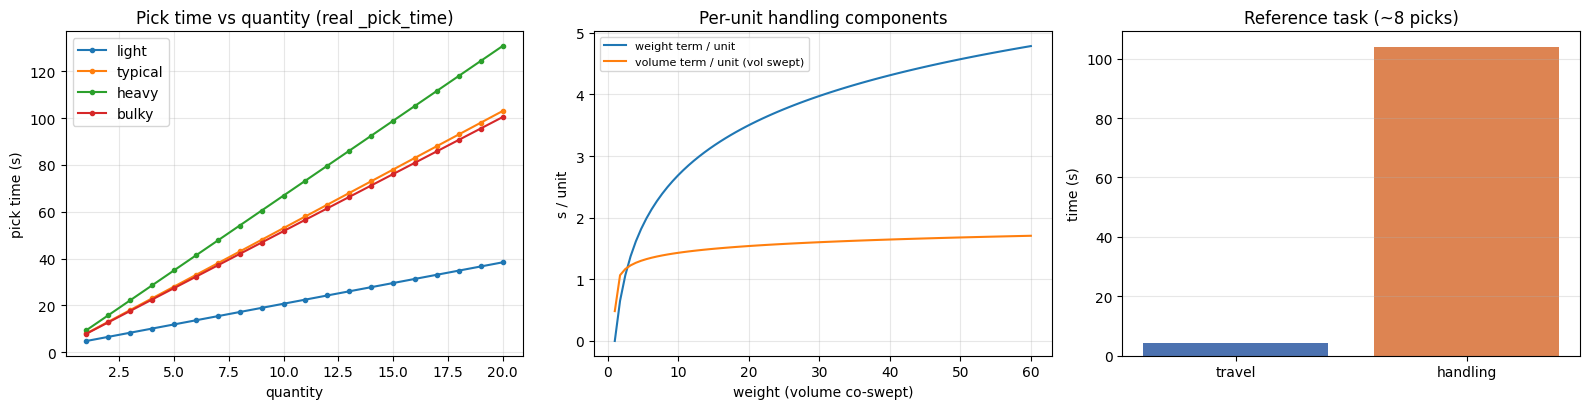

typical pick (qty=2) = 13.0s | one column step = 0.40s | pick:step = 32.5x
reference task: handling 104s (96%) vs travel 4s (4%)

# --- paste this entry into REGRESSION_CONFIGS (Optimization/run_simulation.py) ---
    {
        'name'            : 'calibrated',
        'pick_intercept'  : 3,
        'pick_weight_coef': 1.16833,
        'pick_volume_coef': 0.147007,
        'cart_swap_coef'  : 30,
        'x_speed'         : 0.00833333,
        'y_speed'         : 0.00520833,
    },


In [6]:
# scratch: direct raw-coefficient override example (edit + run)
_ = render(setup_sec=3.0, handle_sec_per_unit=5.0, weight_share=0.7,
           walk_sec_per_column=0.4, walk_sec_per_level=0.25, cart_swap_sec=30.0)